# CNN From Scratch

## Imports

In [1]:
!pip install cupy-cuda12x
!pip install "cutensor-cu12==2.3.*"
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt

# Встановлюємо додатковий оптимізатор тензорів (за бажанням)
try:
    import cupy as cp
    xp = cp
except ImportError:
    xp = np

## Helpful functions

In [2]:
def get_indices(X_shape, HF, WF, stride, pad):
  m, n_C, n_H, n_W = X_shape

  out_h = int((n_H + 2 * pad - HF) / stride) + 1
  out_w = int((n_W + 2 * pad - WF) / stride) + 1

  level1 = xp.repeat(xp.arange(HF), WF)
  level1 = xp.tile(level1, n_C)
  everyLevels = stride * xp.repeat(xp.arange(out_h), out_w)
  i = level1.reshape(-1, 1) + everyLevels.reshape(1, -1)

  slide1 = xp.tile(xp.arange(WF), HF)
  slide1 = xp.tile(slide1, n_C)
  everySlides = stride * xp.tile(xp.arange(out_w), out_h)
  j = slide1.reshape(-1, 1) + everySlides.reshape(1, -1)

  d = xp.repeat(xp.arange(n_C), HF * WF).reshape(-1, 1)
  return i, j, d

def im2col(X, HF, WF, stride, pad):
  X_padded = xp.pad(X, ((0,0), (0,0), (pad, pad), (pad, pad)), mode='constant')
  i, j, d = get_indices(X.shape, HF, WF, stride, pad)
  cols = X_padded[:, d, i, j]
  cols = xp.concatenate(cols, axis=-1)
  return cols

def col2im(dX_col, X_shape, HF, WF, stride, pad):
  N, D, H, W = X_shape

  H_padded, W_padded = H + 2 * pad, W + 2 * pad
  X_padded = xp.zeros((N, D, H_padded, W_padded))

  i, j, d = get_indices(X_shape, HF, WF, stride, pad)

  dX_col_reshaped = xp.array(xp.hsplit(dX_col, N))

  if xp.__name__ == 'cupy':
      import cupyx
      cupyx.scatter_add(X_padded, (slice(None), d, i, j), dX_col_reshaped)
  else:
      xp.add.at(X_padded, (slice(None), d, i, j), dX_col_reshaped)


  if pad == 0:
      return X_padded
  else:
      return X_padded[:, :, pad:-pad, pad:-pad]

In [3]:
def one_hot(Y, length=10):
    one_hot_Y = xp.zeros((length, Y.size))
    one_hot_Y[Y, xp.arange(Y.size)] = 1
    return one_hot_Y

In [4]:
def get_accuracy(Y_pred, Y_true_labels):
    predictions = xp.argmax(Y_pred, axis=0)
    return xp.sum(predictions == Y_true_labels) / Y_true_labels.size

## All Neural Network classes

In [5]:
class Layer:
    def forward(self, input):
        raise NotImplementedError

    def backward(self, output_gradient, learning_rate):
        raise NotImplementedError

    def update(self, learning_rate):
      pass

In [6]:
class Dense(Layer):
  def __init__(self, input_dim, n_count):
    self.W = xp.random.randn(n_count, input_dim) * xp.sqrt(2. / input_dim)
    self.b = xp.zeros((n_count, 1))

    # Кеш проходу
    self.X = None
    self.dW = None
    self.db = None

  def forward(self, X):
    self.X = X

    Z = self.W @ X + self.b
    return Z

  def backward(self, dZ):
    n = self.X.shape[1]

    self.dW = 1 / n * (dZ @ self.X.T)
    self.db = 1 / n * xp.sum(dZ, axis = 1, keepdims = True)

    dX = self.W.T @ dZ
    return dX

  def update(self, alpha):
    self.W -= alpha * self.dW
    self.b -= alpha * self.db


In [22]:
class Conv2D(Layer):
  def __init__(self, in_channels, out_channels, kernel_size, stride = 1, padding = 0):
    self.in_c = in_channels
    self.out_c = out_channels
    self.k = kernel_size
    self.s = stride
    self.p = padding

    self.W = xp.random.randn(out_channels, in_channels, kernel_size, kernel_size) * xp.sqrt(2. / (in_channels * kernel_size * kernel_size))
    self.b = xp.zeros((out_channels, 1))

    self.X = None
    self.X_col = None
    self.dW = None
    self.db = None

  def forward(self, X):
    self.X = X
    N, C, H, W = X.shape

    out_h = (H + 2 * self.p - self.k) // self.s + 1
    out_w = (W + 2 * self.p - self.k)// self.s + 1

    self.X_col = im2col(X, self.k, self.k, self.s, self.p)

    W_row = self.W.reshape(self.out_c, -1)

    Z_col = W_row @ self.X_col + self.b

    Z = Z_col.reshape(self.out_c, N, out_h, out_w).transpose(1, 0, 2, 3)
    return Z

  def backward(self, dZ):
    N, _, out_h, out_w = dZ.shape

    dZ_col = dZ.transpose(1, 0, 2, 3).reshape(self.out_c, -1)

    dW_row = dZ_col @ self.X_col.T
    self.db = xp.sum(dZ_col, axis=1, keepdims=True) / N
    self.dW = (dW_row / N).reshape(self.W.shape)


    W_row = self.W.reshape(self.out_c, -1)
    dX_col = W_row.T @ dZ_col

    dX = col2im(dX_col, self.X.shape, self.k, self.k, self.s, self.p)

    return dX

  def update(self, alpha):
      self.W -= alpha * self.dW
      self.b -= alpha * self.db


In [8]:
class MaxPool2D(Layer):
  def __init__(self, pool_size=2, stride=2):
    self.pool_size = pool_size
    self.stride = stride
    self.X = None
    self.arg_max = None

  def forward(self, X):
    self.X = X
    N, C, H, W = X.shape

    out_h = H // self.pool_size
    out_w = W // self.pool_size

    res = X.reshape(N, C, out_h, self.pool_size, out_w, self.pool_size)
    out = res.max(axis = (3, 5))

    self.arg_max = (out.reshape(N, C, out_h, 1, out_w, 1) == res)
    return out

  def backward(self, dZ):
      N, C, out_h, out_w = dZ.shape

      dZ_reshaped = dZ.reshape(N, C, out_h, 1, out_w, 1)

      dX_reshaped = dZ_reshaped * self.arg_max

      return dX_reshaped.reshape(self.X.shape)

  def update(self, alpha):
    pass


In [9]:
class Flatten(Layer):
    def __init__(self):
        self.input_shape = None

    def forward(self, X):
        self.input_shape = X.shape # Запам'ятовуємо (N, C, H, W)
        # Розплющуємо все, крім першої осі (Батчу)
        # Перетворюємо на (N, C*H*W), а потім транспонуємо для Dense -> (C*H*W, N)
        return X.reshape(X.shape[0], -1).T

    def backward(self, dZ):
        # Отримуємо градієнт від Dense (Features, N)
        # Повертаємо його у форму (N, Features), а потім у (N, C, H, W)
        return dZ.T.reshape(self.input_shape)

    def update(self, alpha):
      pass

In [10]:
class ReLU(Layer):
  def __init__(self):
    self.X = None

  def forward(self, X):
    self.X = X
    return xp.maximum(0, X)

  def backward(self, Z):
    return Z * (self.X > 0)

  def update(self, learning_rate):
    pass

In [11]:
class SoftmaxCrossEntropy:
  def __init__(self):
    self.y_pred = None
    self.Target = None

  def forward(self, Z, Target):
    exp_z = xp.exp(Z - xp.max(Z, axis=0, keepdims=True))
    self.y_pred = exp_z / xp.sum(exp_z, axis=0, keepdims=True)
    self.Target = Target

    n = Target.shape[1]
    self.y_pred = xp.clip(self.y_pred, 1e-15, 1 - 1e-15)
    loss = -(1 / n) * xp.sum(Target * xp.log(self.y_pred))
    return loss, self.y_pred

  def backward(self):
    dZ = self.y_pred - self.Target
    return dZ

  def update(self, learning_rate):
    pass

In [12]:
class Network:
  def __init__(self, loss_fn):
    self.layers = []
    self.loss_fn = loss_fn

  def add(self, layer):
    self.layers.append(layer)

  def forward(self, X):
    out = X
    for layer in self.layers:
      out = layer.forward(out)
    return out

  def train_step(self, X_batch, Target_batch, alpha):
    Z_final = self.forward(X_batch)

    loss, Y_pred = self.loss_fn.forward(Z_final, Target_batch)
    grad = self.loss_fn.backward()

    for layer in reversed(self.layers):
      grad = layer.backward(grad)

    for layer in self.layers:
      layer.update(alpha)

    return loss, Y_pred



## Data preparation

In [13]:
# 1. Завантаження та підготовка на CPU
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0
X_train = X_train.transpose(0, 3, 1, 2)
X_test = X_test.transpose(0, 3, 1, 2)

print(f"Оригінальний формат: {X_train_raw.shape}")
print(f"Формат для нашої CNN: {X_train.shape}")

# 2. Трансфер на GPU
print("Переносимо датасет у відеопам'ять (VRAM)")
X_train_gpu = xp.array(X_train)
y_train_gpu = xp.array(y_train_raw)
X_test_gpu = xp.array(X_test)
y_test_gpu = xp.array(y_test_raw)

Оригінальний формат: (50000, 32, 32, 3)
Формат для нашої CNN: (50000, 3, 32, 32)
Переносимо датасет у відеопам'ять (VRAM)


## Model in action

In [26]:
criterion = SoftmaxCrossEntropy()

model = Network(loss_fn=criterion)

model.add(Conv2D(in_channels=3, out_channels=32, kernel_size=3, padding=1))
model.add(ReLU())
model.add(MaxPool2D(pool_size=2, stride=2))

model.add(Flatten())
model.add(Dense(8192, 256))
model.add(ReLU())
model.add(Dense(256, 10))

In [27]:
epochs = 32
batch_size = 64
alpha = 0.01
n_samples = X_train.shape[0]

In [28]:
import time

X_train_gpu = xp.array(X_train)
y_train_gpu = xp.array(y_train_raw)
for epoch in range(epochs):
    start_time = time.time()

    # Генеруємо перемішані індекси для батчів
    indices = xp.arange(n_samples)
    xp.random.shuffle(indices)

    losses = []
    batch_accs = []

    for i in range(0, n_samples, batch_size):
        # Відбираємо батч і кидаємо на GPU
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train_gpu[batch_idx]

        # Мітки для CIFAR-10 завантажуються як (N, 1), робимо з них 1D масив (N,)
        Y_batch = y_train_gpu[batch_idx].flatten()
        Target = one_hot(Y_batch)

        # Твоя елегантна функція робить ВСЕ: forward, loss, backward, update!
        loss, Y_pred = model.train_step(X_batch, Target, alpha)

        # Збір статистики
        losses.append(float(loss))
        acc = get_accuracy(Y_pred, Y_batch)
        batch_accs.append(float(acc))

    epoch_time = time.time() - start_time
    avg_loss = sum(losses) / len(losses)
    avg_acc = sum(batch_accs) / len(batch_accs)

    print(f"Епоха {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {avg_acc*100:.2f}% | Час: {epoch_time:.1f} сек")

Епоха 1/32 | Loss: 1.8744 | Accuracy: 32.85% | Час: 10.1 сек
Епоха 2/32 | Loss: 1.5670 | Accuracy: 44.68% | Час: 10.1 сек
Епоха 3/32 | Loss: 1.4175 | Accuracy: 49.99% | Час: 10.2 сек
Епоха 4/32 | Loss: 1.3195 | Accuracy: 53.43% | Час: 10.1 сек
Епоха 5/32 | Loss: 1.2478 | Accuracy: 56.26% | Час: 10.0 сек
Епоха 6/32 | Loss: 1.1960 | Accuracy: 57.98% | Час: 10.1 сек
Епоха 7/32 | Loss: 1.1489 | Accuracy: 59.86% | Час: 9.9 сек
Епоха 8/32 | Loss: 1.1081 | Accuracy: 61.36% | Час: 9.9 сек
Епоха 9/32 | Loss: 1.0743 | Accuracy: 62.51% | Час: 10.0 сек
Епоха 10/32 | Loss: 1.0381 | Accuracy: 63.84% | Час: 9.9 сек
Епоха 11/32 | Loss: 1.0049 | Accuracy: 65.29% | Час: 9.9 сек
Епоха 12/32 | Loss: 0.9776 | Accuracy: 66.04% | Час: 10.0 сек
Епоха 13/32 | Loss: 0.9457 | Accuracy: 67.35% | Час: 10.0 сек
Епоха 14/32 | Loss: 0.9202 | Accuracy: 68.13% | Час: 10.0 сек
Епоха 15/32 | Loss: 0.8897 | Accuracy: 69.51% | Час: 9.8 сек
Епоха 16/32 | Loss: 0.8645 | Accuracy: 70.20% | Час: 9.9 сек
Епоха 17/32 | Loss: 0.8

## Testing

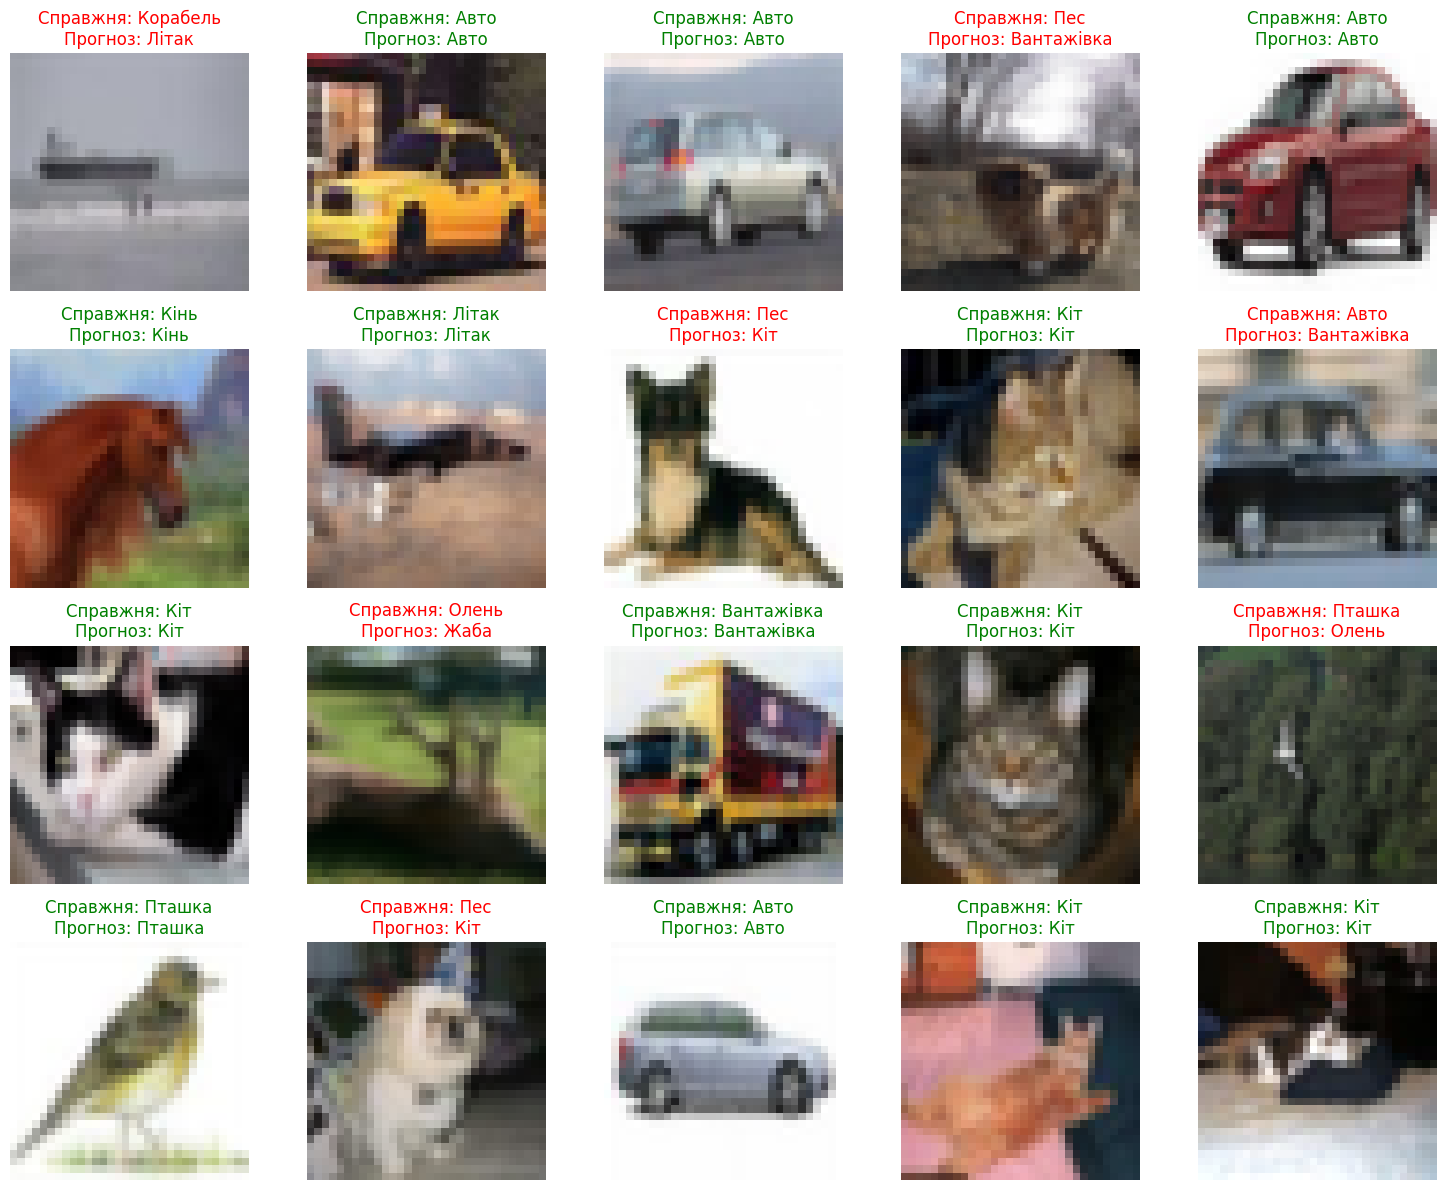

In [29]:
cifar_classes = ['Літак', 'Авто', 'Пташка', 'Кіт', 'Олень',
                 'Пес', 'Жаба', 'Кінь', 'Корабель', 'Вантажівка']

# 2. Беремо 20 випадкових картинок з ТЕСТОВОГО набору
num_samples = 20
indices = xp.random.choice(X_test_gpu.shape[0], num_samples, replace=False)
X_sample = X_test_gpu[indices]
y_true = y_test_gpu[indices].flatten()

# 3. ПРОГАНЯЄМО ЧЕРЕЗ МЕРЕЖУ (Inference)
Z_pred = model.forward(X_sample)

# Наш Dense видає форму (10, Batch). Беремо індекс найбільшого числа у кожному стовпчику
y_pred = xp.argmax(Z_pred, axis=0)

# 4. ПЕРЕНОСИМО ДАНІ З GPU НА CPU для малювання
if xp.__name__ == 'cupy':
    X_draw = X_sample.get()
    y_true_draw = y_true.get()
    y_pred_draw = y_pred.get()
else:
    X_draw = X_sample
    y_true_draw = y_true
    y_pred_draw = y_pred

# 5. МАЛЮЄМО РЕЗУЛЬТАТИ
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i in range(num_samples):
    ax = axes[i]

    # Повертаємо осі для matplotlib: (C, H, W) -> (H, W, C)
    img = X_draw[i].transpose(1, 2, 0)

    # Відображаємо картинку
    ax.imshow(img)
    ax.axis('off')

    # Витягуємо текстові назви
    true_label = cifar_classes[int(y_true_draw[i])]
    pred_label = cifar_classes[int(y_pred_draw[i])]

    # Зелений текст, якщо вгадали, Червоний - якщо помилилися
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"Справжня: {true_label}\nПрогноз: {pred_label}", color=color)

plt.tight_layout()
plt.show()